### Generating csv file

In [1]:
import yfinance as yf
import pandas as pd
import os

# Create data folder if not exists
os.makedirs("data", exist_ok=True)

# Download data (IMPORTANT params)
df = yf.download(
    "RELIANCE.NS",
    start="2020-01-01",
    end="2024-01-01",
    auto_adjust=False,   # important
    group_by="column"    # avoids multi-index
)

# Reset index so Date becomes a column
df.reset_index(inplace=True)

# Save clean CSV
df.to_csv("data/stock_data.csv", index=False)

[*********************100%***********************]  1 of 1 completed


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [15]:
# Step 1: Load raw CSV
df = pd.read_csv("data/stock_data.csv")

# Step 2: Remove junk row permanently
df = df.iloc[1:]

# Step 3: Fix Date
df["Date"] = pd.to_datetime(df["Date"])

# Step 4: Save CLEAN version back
df.to_csv("data/stock_data.csv", index=False)

In [16]:
df = pd.read_csv("data/stock_data.csv")
print(df.columns)
display(df.head())


Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Date,Adj Close,Close,High,Low,Open,Volume
0,2020-01-01,675.324219,690.138306,698.138733,688.263977,693.978516,14004468
1,2020-01-02,686.821228,701.887512,704.470520,691.235535,691.235535,17710316
2,2020-01-03,687.648804,702.733276,704.790527,696.264343,700.835999,20984698
3,2020-01-06,671.700684,686.435303,698.504456,684.835205,694.892883,24519177
4,2020-01-07,682.034546,696.995850,701.521790,691.921265,694.435669,16683622


In [21]:
df = pd.read_csv("data/stock_data.csv", 
                 parse_dates=["Date"], 
                 index_col="Date")
print(df.columns)
df.head()


Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-01,675.324219,690.138306,698.138733,688.263977,693.978516,14004468
2020-01-02,686.821228,701.887512,704.470520,691.235535,691.235535,17710316
2020-01-03,687.648804,702.733276,704.790527,696.264343,700.835999,20984698
2020-01-06,671.700684,686.435303,698.504456,684.835205,694.892883,24519177
2020-01-07,682.034546,696.995850,701.521790,691.921265,694.435669,16683622


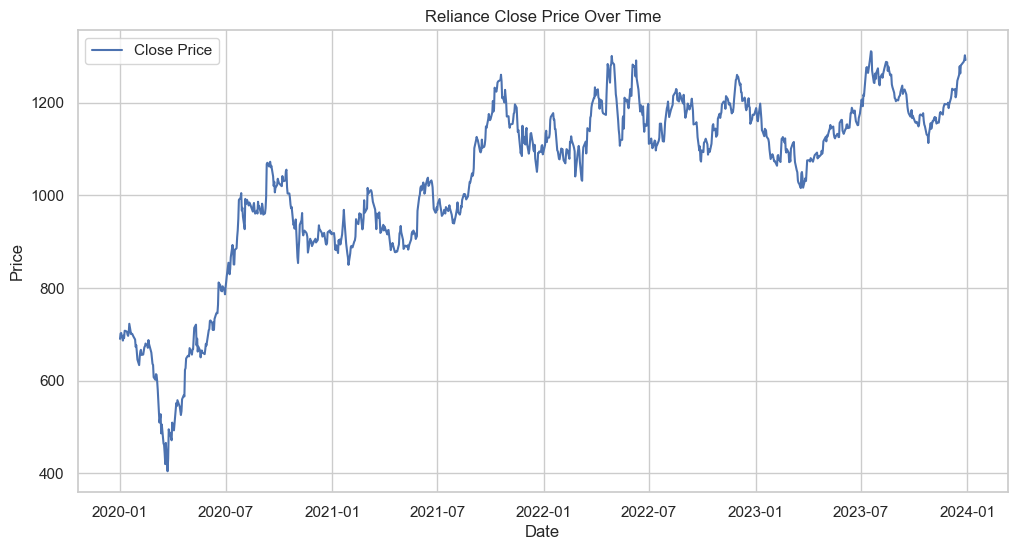

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x=df.index, y='Close', label='Close Price')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Reliance Close Price Over Time')

plt.show()

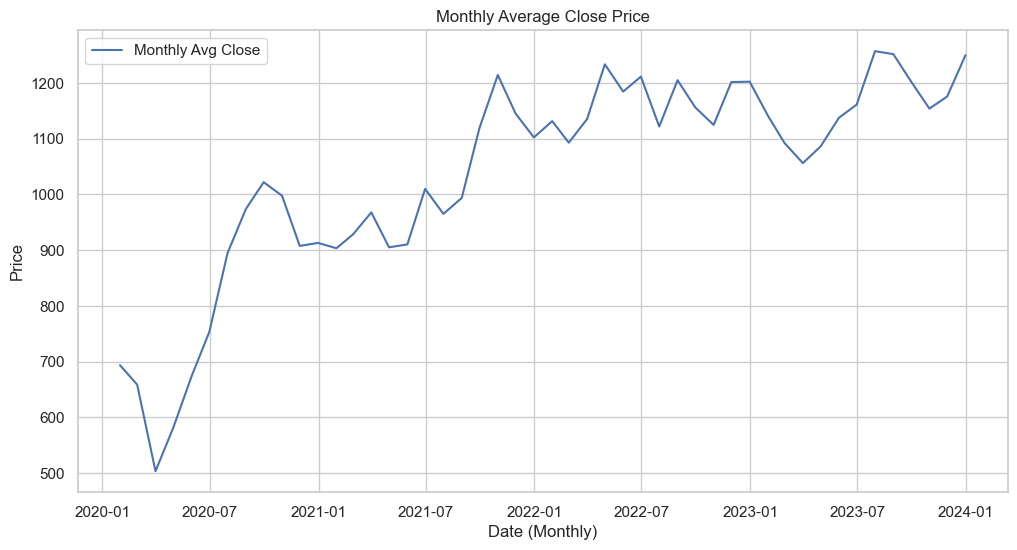

In [23]:
df_resampled = df.resample('ME').mean(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(data=df_resampled, x=df_resampled.index, y='Close', label='Monthly Avg Close')

plt.xlabel('Date (Monthly)')
plt.ylabel('Price')
plt.title('Monthly Average Close Price')

plt.show()

<Figure size 1200x600 with 0 Axes>

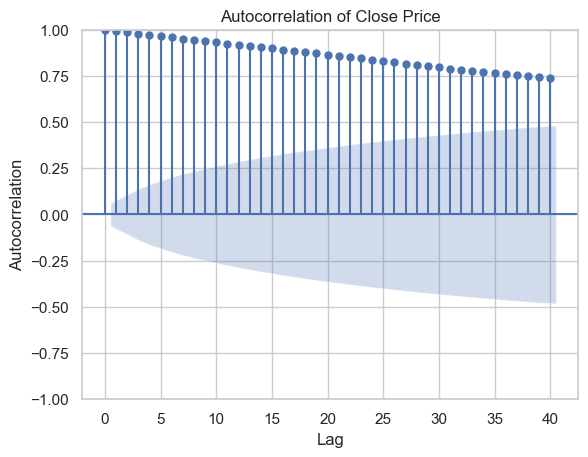

In [24]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plot_acf(df['Close'], lags=40)

plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of Close Price')

plt.show()

In [2]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

ADF Statistic: -1.7421211964544498
p-value: 0.4095513664615975
Critical Values: {'1%': np.float64(-3.4369658620871286), '5%': np.float64(-2.8644609013346485), '10%': np.float64(-2.56832523159495)}


In [3]:
df['close_diff'] = df['Close'].diff()

df = df.dropna()

df[['Close', 'close_diff']].head()

Price,Close,close_diff
Ticker,RELIANCE.NS,
1,701.887512,11.749207
2,702.733276,0.845764
3,686.435303,-16.297974
4,696.995850,10.560547
5,691.761292,-5.234558


In [4]:
result = adfuller(df['close_diff'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -30.763961376011608
p-value: 0.0


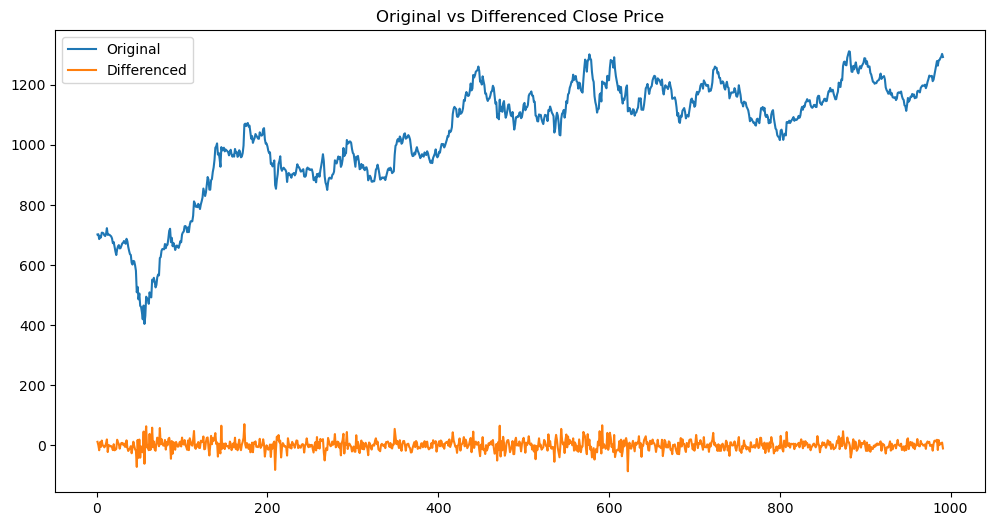

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Original')
plt.plot(df['close_diff'], label='Differenced')

plt.legend()
plt.title("Original vs Differenced Close Price")

plt.show()

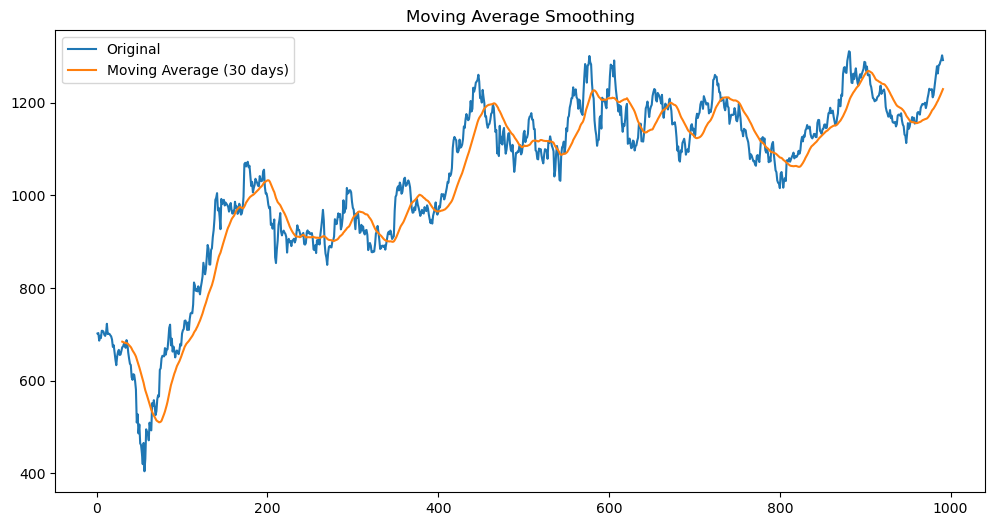

In [6]:
window_size = 30

df['moving_avg'] = df['Close'].rolling(window=window_size).mean()

plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Original')
plt.plot(df['moving_avg'], label='Moving Average (30 days)')

plt.legend()
plt.title("Moving Average Smoothing")

plt.show()

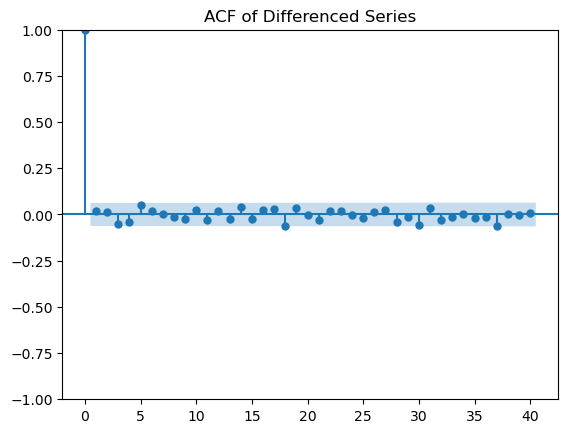

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['close_diff'], lags=40)
plt.title("ACF of Differenced Series")
plt.show()

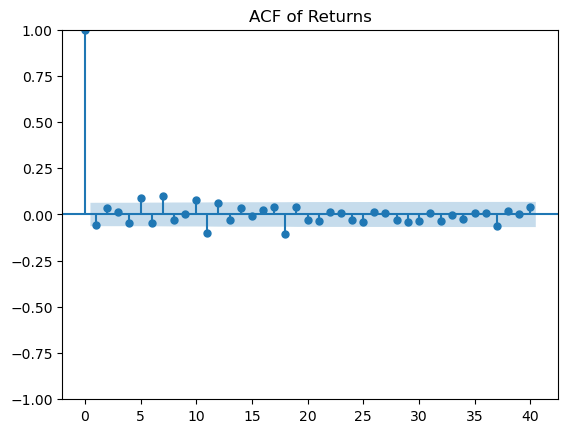

In [8]:
df['returns'] = df['Close'].pct_change()

df = df.dropna()

plot_acf(df['returns'], lags=40)
plt.title("ACF of Returns")
plt.show()